In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import yaml
ROOT = os.path.abspath("..")
sys.path.append(os.path.join(ROOT, "src"))

In [4]:
env_name = "C1_203"
algo = "PPO"
model_name = "C1_203_H_H09_run_5"


In [5]:
C_path = f'env_config/discrete_joint/{env_name}.yaml'  # Default path for environment configuration
with open(f"{ROOT}/{C_path}", 'r') as f:
        env_cfg = yaml.load(f, Loader=yaml.SafeLoader)

env_params = env_cfg.copy()
project_name = env_params['env']['name']
delta_t = env_params['env']['time_step']          # Time step in hours
total_t = env_params['env']['Total_time']          # Total simulation time in hours
timelimit = int(np.ceil(total_t / delta_t))

In [6]:
data = np.load(f"{ROOT}/results/{project_name}/{env_name}/RL_Model/{algo}/{model_name}/state_hist_final.npz")
hist = data["hist"]
print(hist.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/arghavanzibaie/Documents/GitHub/Industrial-Refrigeration/results/Ref_simple/C1_203/RL_Model/PPO/C1_203_H_H09_run_5/state_hist_final.npz'

In [28]:
n = 62
room_1 = np.linspace(-22.1, -15.9, num=n, dtype=np.float64)
room_2 = np.linspace(-22.1, -15.9, num=n, dtype=np.float64)
mesh_x, mesh_y = np.meshgrid(room_1, room_2)
obs_array = np.stack([mesh_x.ravel(), mesh_y.ravel()], axis=1).astype(np.float64)

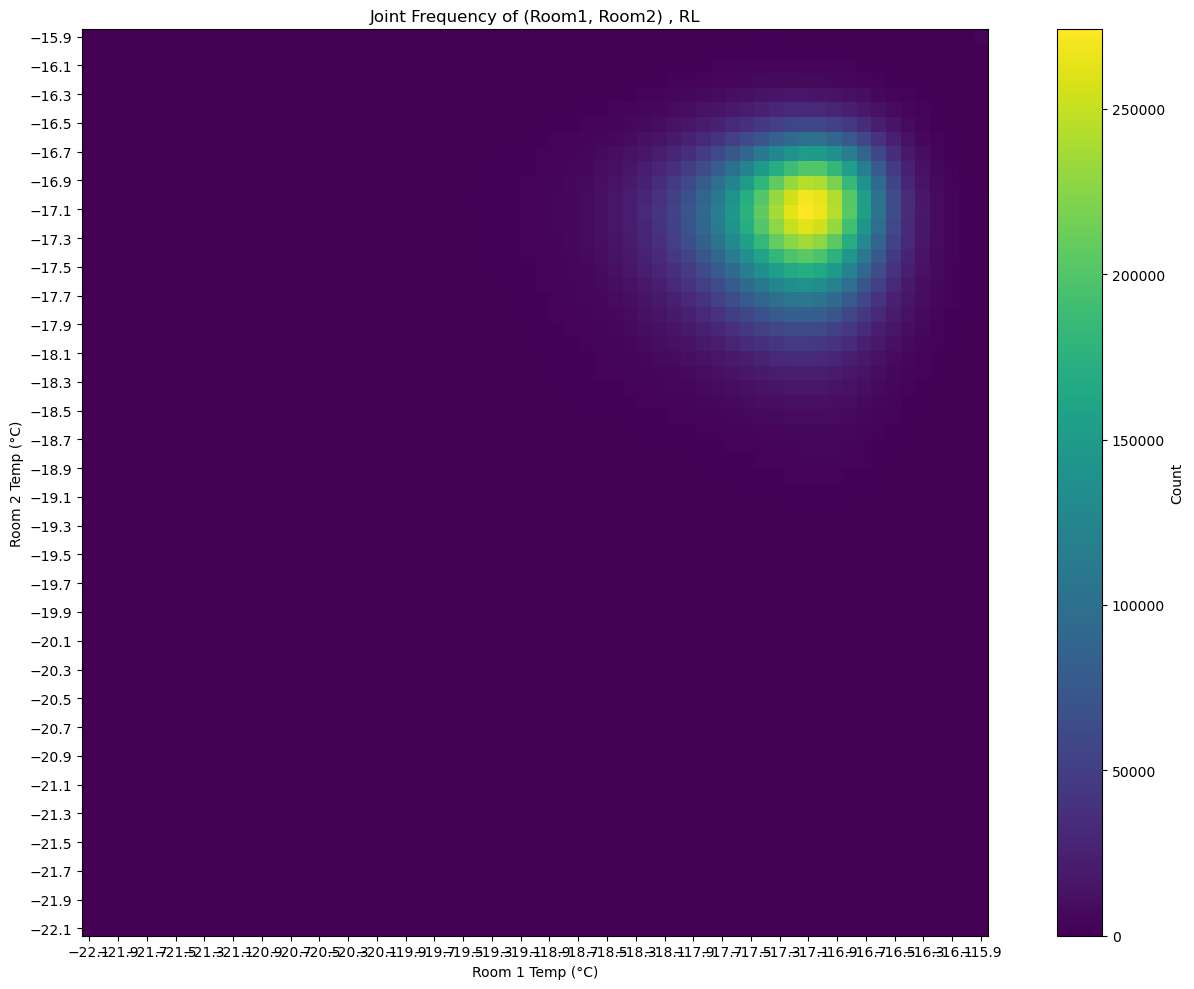

In [29]:
## plot the histogram 
fig , ax = plt.subplots(figsize=(14, 10))
m = ax.pcolormesh(mesh_x, mesh_y, hist)   # or 'freq.T' to plot normalized frequencies
fig.colorbar(m, ax=ax, label="Count")      # change to "Frequency" if using freq
ax.set_xlabel("Room 1 Temp (°C)")
ax.set_ylabel("Room 2 Temp (°C)")
ax.set_title("Joint Frequency of (Room1, Room2) , RL")
ax.set_aspect('equal')
plt.tight_layout()
plt.xticks(np.arange(-22.1, -15.9, 0.2))  
plt.yticks(np.arange(-22.1, -15.9, 0.2))

plt.show()